# Assignment 7: Creating New Symbols for Digits

**Data:**

The dataset is obtained from Arabic Handwritten Digits Dataset | Kaggle , original source unknown. 

**Problem Statement:**

You are working with a team that is developing an online game where users travel to an alien planet and try to learn the language, culture, religion, and science of the planetary society. The game designers would like a set of characters to represent digits, different from any of those used on earth. To develop this set of characters, your job is to train a GAN on Arabic Handwritten digits and use it to create new symbols for representing digits on an alien planet.


In [4]:
import matplotlib.pyplot as plt

import pandas as pd
# Import the required library functions
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Reshape, Dense, Dropout, Flatten,Activation
from tensorflow.keras.layers import LeakyReLU,BatchNormalization
from tensorflow.keras.layers import Conv2D, UpSampling2D,Conv2DTranspose
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam


# 1. Data
## 1.1 Load Data
Each row of the train and test datafiles contain gray scale values of a 28 x 28 image. Load these CSV files into pandas dataframes, Convert the dataframes into numpy arrays using pandas.values. Print the shape of each dataframe.

In [5]:
df_train = pd.read_csv('csvTrainImages 60k x 784.csv', header=None)
df_test = pd.read_csv('csvTestImages 10k x 784.csv', header=None)

X_train = df_train.values
X_test = df_test.values

print('Train dataset shape:', df_train.shape)
print('Test dataset shape:', df_test.shape)

Train dataset shape: (60000, 784)
Test dataset shape: (10000, 784)


## 1.2 Normalize both dataframes
Normalize both dataframes by dividing each value by 255. Reshape the array so each image is 28 x 28 using numpy.ndarray.reshape. Use matplotlib.plot.imshow and matplotlib.plot.subplot to give a plot of the first 25 training images in a 5x5 subplot, using the 'gray' colour map.

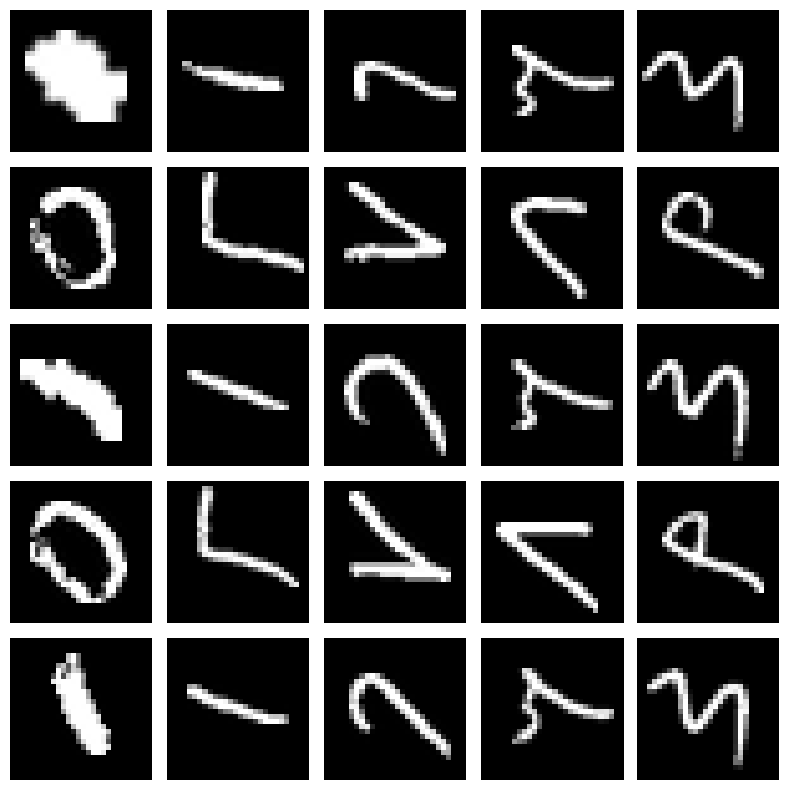

Train value range: 0.0 1.0
Test value range: 0.0 1.0


In [6]:
# Normalize pixel values only when needed
if df_train.to_numpy().max() > 1.0:
    df_train = df_train / 255.0
if df_test.to_numpy().max() > 1.0:
    df_test = df_test / 255.0

# Convert normalized dataframes back to numpy arrays
X_train = df_train.values
X_test = df_test.values

# Reshape flattened vectors to 28x28 grayscale images
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# Plot the first 25 training images in a 5x5 grid
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

print('Train value range:', float(X_train.min()), float(X_train.max()))
print('Test value range:', float(X_test.min()), float(X_test.max()))

## 1.3 Load the label CSV
Load the label CSV files into dataframes and convert them to numpy arrays using pandas.values. Reshape them into 2d numpy arrays

In [7]:
# Load the label data for training and testing.
train_label = pd.read_csv('csvTrainLabel 60k x 1.csv', header=None)
test_label = pd.read_csv('csvTestLabel 10k x 1.csv', header=None)
print('Train labels shape:', train_label.shape)
print('Test labels shape:', test_label.shape)


# Reshape label data to 2D numpy arrays
y_train = train_label.values.reshape(-1, 1)
y_test = test_label.values.reshape(-1, 1)

print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

Train labels shape: (60000, 1)
Test labels shape: (10000, 1)
y_train shape: (60000, 1)
y_test shape: (10000, 1)


# 2. Modeling
## 2.1 Create a function that generates real sample of data from the training dataset.


In [8]:
# Function to generate real data samples
def realData(batch):
    # Get the training data loaded earlier in the notebook
    X = X_train.astype('float32')

    # Reshaping the input data to include channel
    if X.ndim == 3:
        X = X[:, :, :, np.newaxis]

    # Match generator tanh output range: [-1, 1]
    X = (X * 2.0) - 1.0

    # Generate a random batch of real samples
    imageBatch = X[np.random.randint(0, X.shape[0], size=batch)]
    return imageBatch

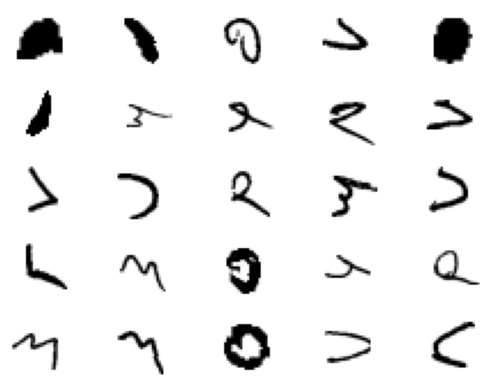

In [9]:
# Generating a batch of  images
arabic_digit = realData(25)

 # Plotting the images

for j in range(5*5):
    pyplot.subplot(5,5,j+1)
    # turn off axis 
    pyplot.axis('off') 
    pyplot.imshow(arabic_digit[j,:,:,0],cmap='gray_r')

## 2.2 Fake data generator
Create a function to generate inputs for the fake data generator function.

In [10]:
# Function to generate inputs for generator function
def fakeInputs(batch,infeats):
    # Generate random noise data with shape (batch,input features)
    x_fake = np.random.uniform(-1,1,size=[batch,infeats])
    return x_fake

## 2.3 compile a generator model
Define and compile a generator model

In [11]:
# Function for the generator model
def genModel(infeats):
    # Defining the Generator model
    Genmodel = Sequential()
    Genmodel.add(Dense(512,input_dim=infeats))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization())
    # second layer of FC => RElu => BN layers
    Genmodel.add(Dense(7*7*64))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization())
    # Upsample to 14 x 14
    Genmodel.add(Reshape((7,7,64)))
    Genmodel.add(Conv2DTranspose(32,kernel_size=(5,5),strides=(2,2),padding='same'))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization(axis = -1))
    # Updample to 28 x 28
    Genmodel.add(Conv2DTranspose(1,kernel_size=(5,5),strides=(2,2),padding='same'))
    Genmodel.add(Activation('tanh'))    
    return Genmodel


In [12]:
# Define the arguments like batch size and input feature
batch = 128
infeats = 100
Genmodel = genModel(infeats)
Genmodel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               51712     
                                                                 
 activation (Activation)     (None, 512)               0         
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 3136)              1608768   
                                                                 
 activation_1 (Activation)   (None, 3136)              0         
                                                                 
 batch_normalization_1 (Batc  (None, 3136)             12544     
 hNormalization)                                        

## 2.4  fake samples generator
Create a function to generate fake samples using the generator model, taking input from the function created in part b.

In [13]:
# Function to create fake samples using the generator model
def fakedataGenerator(Genmodel, batch, infeats):
    # First generate the random inputs to the model
    genInputs = fakeInputs(batch, infeats)
    # Use these inputs inside the generator model to generate fake distribution
    X_fake = Genmodel.predict(genInputs, verbose=0)

    return X_fake

In [14]:
# Generating a fake sample and printing the shape
fake = fakedataGenerator(Genmodel,batch,infeats)
fake.shape

(128, 28, 28, 1)

Text(0.5, 0, 'Fake Sample Image')

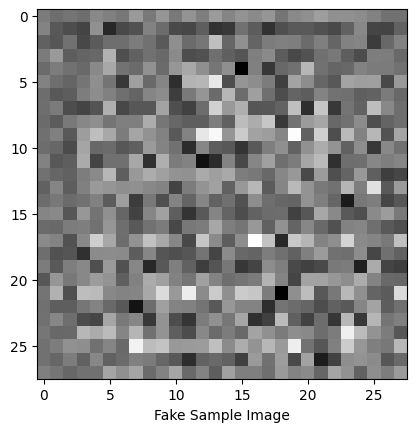

In [15]:
# Plotting the fake sample

plt.imshow(fake[1, :, :, 0], cmap='gray_r')
 
plt.xlabel('Fake Sample Image') 

## 2.5 compile a discriminator model
Define and compile a discriminator model

In [16]:
# Descriminator model as a function
def discModel():
    Discmodel = Sequential()
    Discmodel.add(Conv2D(32,kernel_size=(5,5),strides=(2,2),padding='same',input_shape=(28,28,1)))    
    Discmodel.add(LeakyReLU(0.2))
    # second layer of convolutions
    Discmodel.add(Conv2D(64, kernel_size=(5,5), strides=(2, 2), padding='same'))   
    Discmodel.add(LeakyReLU(0.2))
    # Fully connected layers
    Discmodel.add(Flatten())
    Discmodel.add(Dense(512))
    Discmodel.add(LeakyReLU(0.2))
    Discmodel.add(Dense(1, activation='sigmoid'))
    Discmodel.compile(loss='binary_crossentropy', optimizer=Adam(lr=0.0002, beta_1=0.5),metrics=['accuracy'])   
    return Discmodel 

In [17]:
# Print the summary of the discriminator model
Discmodel = discModel()
Discmodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 32)        832       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 64)          51264     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 7, 7, 64)          0         
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               1606144   
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 512)              

c:\Users\danie\anaconda3\envs\dl_39\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


## 2.6 compile GAN model
Define and compile a GAN model from the generator and discriminator models; be sure to set the discriminator part to be untrainable

In [18]:
# Define the combined generator and discriminator model, for updating the generator
def ganModel(Genmodel, Discmodel):
    # Set discriminator model to untrainable inside GAN
    Discmodel.trainable = False
    Ganmodel = Sequential()
    # First add generator, then discriminator
    Ganmodel.add(Genmodel)
    Ganmodel.add(Discmodel)
    # Compile GAN model for updating generator weights
    Ganmodel.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return Ganmodel

In [19]:
# Initialise the gan model
gan_model = ganModel(Genmodel,Discmodel)
# Print summary of the GAN model
gan_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 28, 28, 1)         1727233   
                                                                 
 sequential_1 (Sequential)   (None, 1)                 1658753   
                                                                 
Total params: 3,385,986
Trainable params: 1,719,873
Non-trainable params: 1,666,113
_________________________________________________________________


## 2.7 Training
Train the GAN network using tf.keras.train_on_batch.

In [20]:
# Defining the number of epochs
nEpochs = 5000

In [21]:
# Train the GAN network
for i in range(nEpochs):
    # Generate samples equal to the bath size from the real distribution
    x_real = realData(batch)
    # Generate fake samples using the fake data generator function
    x_fake = fakedataGenerator(Genmodel,batch,infeats)
    # Concatenating the real and fake data 
    X = np.concatenate([x_real,x_fake])
    # Creating the dependent variable and initializing them as '0'
    Y = np.zeros(batch * 2)
    # making the first set equivalent to batch with labels 1
    Y[:batch] = 1
    # train the  discriminator on the real samples
    discLoss = Discmodel.train_on_batch(X, Y)
    # Generate new fake inputs for training the GAN network
    x_gan = fakeInputs(batch*2,infeats)
    # Create labels of the fake examples as 1 to fool the discriminator
    y_gan = np.ones((batch*2, 1))
    # Update the generator model through the discriminator model
    gan_model.train_on_batch(x_gan, y_gan)
    # Print the accuracy measures on the real and fake data for every 10 epochs
    if (i) % 50 == 0:
        # Printing the descriminator loss and accuracy
        x_real_test = realData(10)
        x_fake_test = fakedataGenerator(Genmodel,10,infeats)
        # Concatenating the real and fake data 
        X_test = np.concatenate([x_real_test,x_fake_test])
        # Creating the dependent variable and initializing them as '0'
        Y = np.zeros(20 * 2)
        Y[:10] = 1
        # Predicting probabilities
        preds = Discmodel.predict(X_test)
        print('Discriminator probability:{D}'.format(D=np.mean(preds)))
        # Generate fake samples using the fake data generator function
        x_fake = fakedataGenerator(Genmodel,batch,infeats)
        # Saving the plots
        for j in range(5*5):
            pyplot.subplot(5,5,j+1)
            # turn off axis 
            pyplot.axis('off')
            pyplot.imshow(x_fake[j,:,:,0],cmap='gray_r')                       
        filename = 'handwritten/Gan_Arabic_Handwritten_Training_Plot%03d.png' % (i)
        pyplot.savefig(filename)
        pyplot.close()
            

1/1 [==============================] - 0s 44ms/step
Discriminator probability:0.5670661330223083
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.5024360418319702
1/1 [==============================] - 0s 13ms/step
Discriminator probability:0.5011395812034607
1/1 [==============================] - 0s 13ms/step
Discriminator probability:0.5179908275604248
1/1 [==============================] - 0s 13ms/step
Discriminator probability:0.4156663417816162
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.5333873629570007
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.44092464447021484
1/1 [==============================] - 0s 18ms/step
Discriminator probability:0.33041030168533325
1/1 [==============================] - 0s 14ms/step
Discriminator probability:0.725509762763977
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.41828054189682007
1/1 [=======================

# 3. Conclusions
## 3.1 Generating Fake Images
Generate 25 fake images and display them in a 5x5 grid. If the images do not look realistic, revisit the modeling section to improve the generator model. Record in markdown the adjustments you have made to get the model working well. Keep and display the image plots for each version of the model you try.

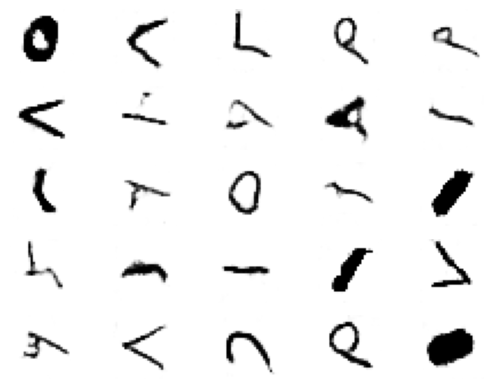

In [30]:
fake_images = fakedataGenerator(Genmodel,batch,infeats)
# Saving the plots
for j in range(5*5):
    pyplot.subplot(5,5,j+1)
    # turn off axis 
    pyplot.axis('off')
    pyplot.imshow(fake_images[j,:,:,0],cmap='gray_r')

### Previous model explored
- We built a GAN made of two models trained together: a generator and a discriminator.
- The generator starts from a 100-dimensional noise vector and learns to turn it into an image.
  - We pass the noise through fully connected layers with ReLU and batch normalization.
  - We reshape it into a 7×7 feature map and upsample it using transposed convolutions.
  - We output a 28×28 grayscale image using tanh so pixel values are between -1 and 1.

- The discriminator does the opposite: it takes a 28×28 image and decides if it’s real or fake.
  - We use convolutional layers with LeakyReLU to reduce the image step by step.
  - We flatten the result and output a single probability (real vs fake).

- Training setup:
  - 12,450 epochs, batch size of 128, Adam optimizer (learning rate = 0.0002).
  - We train the discriminator first on real and generated images.
  - Then we train the generator to fool the discriminator.

- Over time, both models improve together, and we end up generating realistic-looking digit images.

### What We Changed To Improve Results

Compared with the baseline we explored in class, we made the workflow more focused on quality and selection instead of just plotting random samples. The baseline discriminator used a lighter setup (32 and 64 filters with a Dense 512 layer). In our improved version, the discriminator was moved toward a stronger DCGAN-style design by increasing convolution capacity to 64 and 128 filters and adding Dropout, which helps regularize training and reduce overfitting to easy patterns.

After training, we also improved how we evaluate outputs. Instead of looking at one random batch of fake images, we now use the real labeled dataset to build digit prototypes (0-9), generate many fake samples, and keep 10 candidate images per digit based on closest prototype match (MSE). This gives a much cleaner way to review options and manually pick the best final 0-9 symbols from the model.

## 3.2 Selecting the best 10 images of the model
Use the labeled training set to create one prototype per digit (0-9), then group generated images by closest prototype and keep 10 candidates per digit. After visualization, pick one index per digit to produce your final best 0-9 set.

### 3.2.1 Generating Images grouped by Label:
The first thing we did was to generate a list of real images + label from the training dataset by averaging real images grouped by digit.

In [36]:
# Build labeled prototypes directly from the real training set.
X_ref = X_train.astype('float32')
X_ref = X_ref[..., np.newaxis]

# Match generator image range to compare real and fake images consistently.
X_ref = (X_ref * 2.0) - 1.0

y_ref = y_train.reshape(-1).astype(int)
# Generating prototypes for each digit class by averaging the real images in the training set.
digit_prototypes = []
for d in range(10):
    digit_real = X_ref[y_ref == d]
    digit_prototypes.append(np.mean(digit_real, axis=0))

digit_prototypes = np.array(digit_prototypes, dtype=np.float32)
print('digit_prototypes shape:', digit_prototypes.shape)

digit_prototypes shape: (10, 28, 28, 1)


Generating fake images and assigning each fake to the closest digit prototype (MSE distance), then keeping 10 candidates per digit with the best scores so we can pick from them in a future iteration.

In [32]:
# Build a candidate bank: 10 generated images per digit (0-9),
# by assigning each fake image to the closest labeled digit prototype.
def build_digit_candidate_bank(generator, prototypes, infeats, samples_per_digit=10, gen_batch=512, max_rounds=300):
    buckets = {d: [] for d in range(10)}
    distances = {d: [] for d in range(10)}

    for _ in range(max_rounds):
        z = fakeInputs(gen_batch, infeats)
        fake_batch = generator.predict(z, verbose=0)  # range [-1, 1]

        # MSE distance from each fake image to each digit prototype.
        diff = fake_batch[:, None, :, :, :] - prototypes[None, :, :, :, :]
        mse = np.mean(diff ** 2, axis=(2, 3, 4))  # shape: (batch, 10)

        pred_digit = np.argmin(mse, axis=1)
        pred_distance = np.min(mse, axis=1)

        for img, d, dist in zip(fake_batch, pred_digit, pred_distance):
            d = int(d)
            dist = float(dist)

            if len(buckets[d]) < samples_per_digit:
                buckets[d].append(img)
                distances[d].append(dist)
            else:
                worst_i = int(np.argmax(distances[d]))
                if dist < distances[d][worst_i]:
                    buckets[d][worst_i] = img
                    distances[d][worst_i] = dist

        if all(len(buckets[d]) >= samples_per_digit for d in range(10)):
            break

    if not all(len(buckets[d]) >= samples_per_digit for d in range(10)):
        raise RuntimeError('Could not collect enough samples for all digits. Increase max_rounds.')

    ordered_images = []
    ordered_scores = []
    for d in range(10):
        order = np.argsort(distances[d])  # lower distance = better match
        ordered_images.append(np.array([buckets[d][i] for i in order], dtype=np.float32))
        ordered_scores.append(np.array([distances[d][i] for i in order], dtype=np.float32))

    return np.array(ordered_images), np.array(ordered_scores)

digit_candidates, digit_candidate_scores = build_digit_candidate_bank(
    Genmodel, digit_prototypes, infeats, samples_per_digit=10, gen_batch=512, max_rounds=300
)

# Shape: (10 digits, 10 candidates, 28, 28, 1)
print('digit_candidates shape:', digit_candidates.shape)
print('digit_candidate_scores shape:', digit_candidate_scores.shape)

digit_candidates shape: (10, 10, 28, 28, 1)
digit_candidate_scores shape: (10, 10)


Showing the 10x10 candidate grid and a score table (lower score means better prototype match).

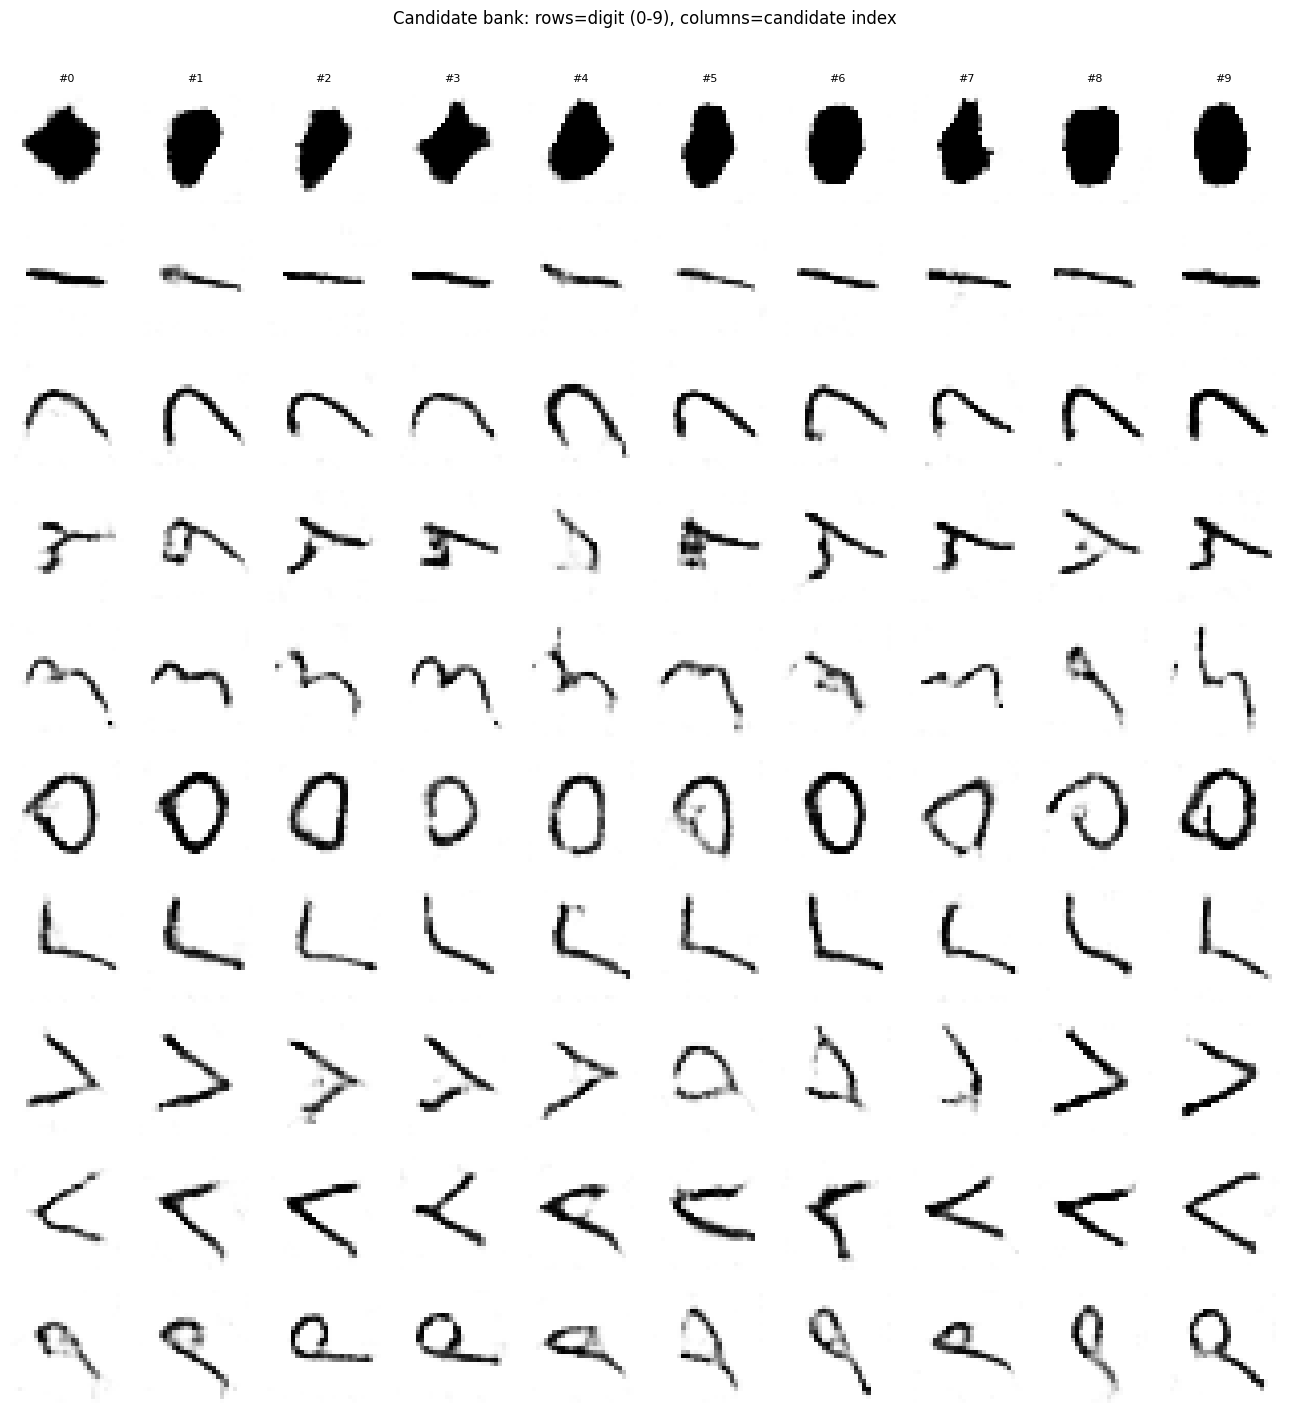

,idx_0,idx_1,idx_2,idx_3,idx_4,idx_5,idx_6,idx_7,idx_8,idx_9
digit_0,0.167227,0.169714,0.179896,0.181554,0.184414,0.185298,0.186159,0.193647,0.200421,0.201188
digit_1,0.026492,0.030186,0.032616,0.033019,0.033372,0.033543,0.033858,0.034135,0.036299,0.036841
digit_2,0.085237,0.093263,0.097452,0.100595,0.101489,0.102289,0.103096,0.103444,0.105346,0.108115
digit_3,0.079890,0.092480,0.095112,0.098078,0.098079,0.101647,0.101868,0.105350,0.107577,0.109820
digit_4,0.073919,0.079817,0.084735,0.086287,0.089171,0.092596,0.094342,0.105844,0.107557,0.109162
digit_5,0.139896,0.145313,0.149491,0.164679,0.167396,0.179482,0.180946,0.187583,0.191232,0.194731
digit_6,0.051118,0.067425,0.067971,0.069319,0.071084,0.071894,0.075185,0.076538,0.077215,0.079067
digit_7,0.101509,0.101741,0.102212,0.102829,0.103353,0.107272,0.120935,0.121556,0.130648,0.139331
digit_8,0.095262,0.099815,0.106583,0.111577,0.113419,0.127092,0.127591,0.128379,0.131647,0.131659
digit_9,0.084397,0.091140,0.096153,0.102217,0.102290,0.104726,0.106323,0.107936,0.115431,0.115528


In [33]:
# Visualize 10 candidates per digit.
def plot_digit_candidate_grid(digit_candidates, digit_candidate_scores=None):
    rows, cols = digit_candidates.shape[0], digit_candidates.shape[1]
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.4))

    for d in range(rows):
        for c in range(cols):
            ax = axes[d, c]
            img = (digit_candidates[d, c, :, :, 0] + 1.0) / 2.0
            ax.imshow(img, cmap='gray_r')
            ax.axis('off')
            if d == 0:
                ax.set_title(f'#{c}', fontsize=8)
            if c == 0:
                ax.set_ylabel(str(d), rotation=0, labelpad=12, fontsize=9)

    plt.suptitle('Candidate bank: rows=digit (0-9), columns=candidate index', y=1.01)
    plt.tight_layout()
    plt.show()

plot_digit_candidate_grid(digit_candidates, digit_candidate_scores)

# Lower score is better here (MSE distance to the real digit prototype).
score_table = pd.DataFrame(
    digit_candidate_scores,
    index=[f'digit_{d}' for d in range(10)],
    columns=[f'idx_{i}' for i in range(10)]
)
score_table

Picking the best generated digits based on shape, scores (MSE) and comparison with other generated digits.

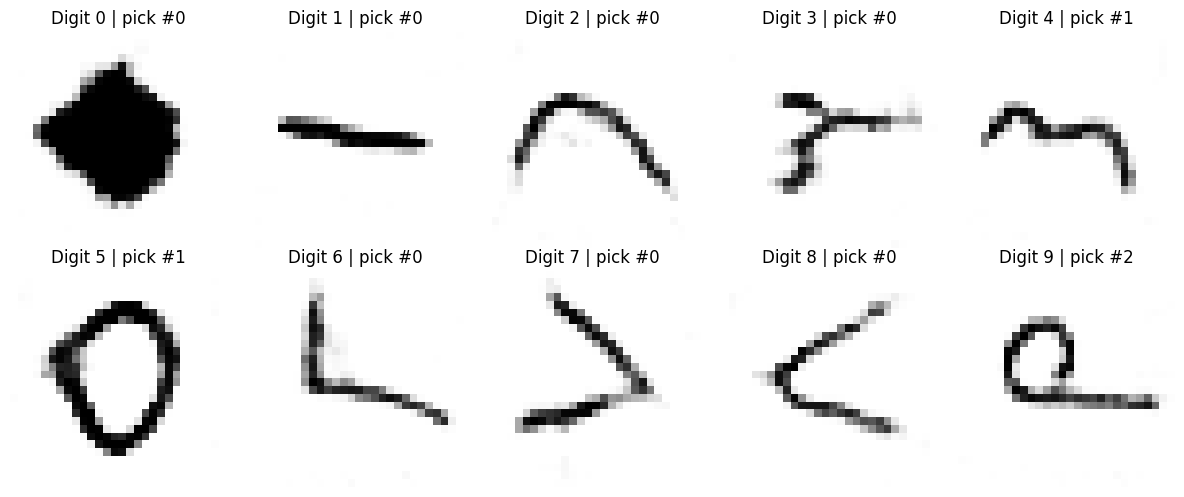

In [42]:
# Choosing one candidate index per digit based on the obtained results.
picked_index_per_digit = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 2], dtype=int)

# Best images for digits 0-9 using your selected candidate indices.
best_0_to_9 = np.stack(
    [digit_candidates[d, picked_index_per_digit[d]] for d in range(10)],
    axis=0
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for d, ax in enumerate(axes.flatten()):
    img = (best_0_to_9[d, :, :, 0] + 1.0) / 2.0
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Digit {d} | pick #{picked_index_per_digit[d]}')
    ax.axis('off')

plt.tight_layout()
plt.show()